<a href="https://colab.research.google.com/github/Darakhshannazir/streaming-subscriber-ltv-system/blob/main/02_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing & Importing libraries

In [ ]:
!pip install "numpy==1.26.4" xgboost==2.0.3 shap==0.44.1 lifelines mlflow joblib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import shutil
import io
import os
from lifelines import KaplanMeierFitter
from google.colab import files
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,
                             mean_absolute_error, r2_score)
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost
import joblib

np.random.seed(42)
print(f"NumPy version: {np.__version__}")
print("Libraries imported")

NumPy version: 1.26.4
Libraries imported


# Step # 1 Upload Features File

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
features = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Loaded: {features.shape}")

Saving subscriber_features.csv to subscriber_features.csv
Loaded: (19998, 22)


# Step # 2 Data Preprocessing

In [ ]:
# Prepare features for ML
# Define which columns go into the model
feature_cols = [
    'total_ratings', 'avg_rating', 'rating_std',
    'last_active_days', 'watch_frequency',
    'genre_affinity_score', 'genre_encoded',
    'plan_encoded', 'acq_encoded'
]

# Target variables
churn_target = 'churned'
ltv_target   = 'iltv'

# Split features and targets
X = features[feature_cols]
y_churn = features[churn_target]
y_ltv   = features[ltv_target]

# Train / test split — 80% train, 20% test
X_train, X_test, y_churn_train, y_churn_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

_, _, y_ltv_train, y_ltv_test = train_test_split(
    X, y_ltv, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Churn rate (train): {y_churn_train.mean():.1%}")
print(f"Churn rate (test) : {y_churn_test.mean():.1%}")

Train size : (15998, 9)
Test size  : (4000, 9)
Churn rate (train): 23.1%
Churn rate (test) : 23.1%


# Step # 3 Model Training & Evaluation (Churn)

In [ ]:
#Train XGBoost churn model
# Calculate scale_pos_weight to handle class imbalance
scale_pos_weight = (y_churn_train == 0).sum() / (y_churn_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Start MLflow experiment tracking
mlflow.set_experiment("StreamVault_LTV")

with mlflow.start_run(run_name="xgb_churn_v1"):

    # Define model
    churn_model = xgb.XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        base_score        = 0.5,
        scale_pos_weight  = scale_pos_weight,
        use_label_encoder = False,
        eval_metric       = 'auc',
        random_state      = 42
    )

    # Train
    churn_model.fit(
        X_train, y_churn_train,
        eval_set=[(X_test, y_churn_test)],
        verbose=50
    )

    # Evaluate
    y_pred_proba = churn_model.predict_proba(X_test)[:, 1]
    y_pred       = churn_model.predict(X_test)
    auc          = roc_auc_score(y_churn_test, y_pred_proba)

    print(f"\nAUC Score: {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_churn_test, y_pred))

    # Log everything to MLflow
    mlflow.log_param("n_estimators",     300)
    mlflow.log_param("max_depth",        6)
    mlflow.log_param("learning_rate",    0.05)
    mlflow.log_metric("auc",             auc)
    mlflow.xgboost.log_model(churn_model, "churn_model")

print("Churn model trained and logged to MLflow")


scale_pos_weight: 3.33


2026/04/14 19:33:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/14 19:33:39 INFO mlflow.store.db.utils: Updating database tables
2026/04/14 19:33:41 INFO mlflow.tracking.fluent: Experiment with name 'StreamVault_LTV' does not exist. Creating a new experiment.


[0]	validation_0-auc:0.64066
[50]	validation_0-auc:0.80566
[100]	validation_0-auc:0.80645
[150]	validation_0-auc:0.80465
[200]	validation_0-auc:0.80355
[250]	validation_0-auc:0.80211
[299]	validation_0-auc:0.80024

AUC Score: 0.8002

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      3077
           1       0.46      0.75      0.57       923

    accuracy                           0.74      4000
   macro avg       0.68      0.74      0.69      4000
weighted avg       0.80      0.74      0.76      4000



2026/04/14 19:33:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 19:33:52 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp55fan8as/model, flavor: xgboost). Fall back to return ['xgboost==2.0.3']. Set logging level to DEBUG to see the full traceback. 


Churn model trained and logged to MLflow
churn_model.pkl saved


# Step # 4 Feature Importance (Churn)

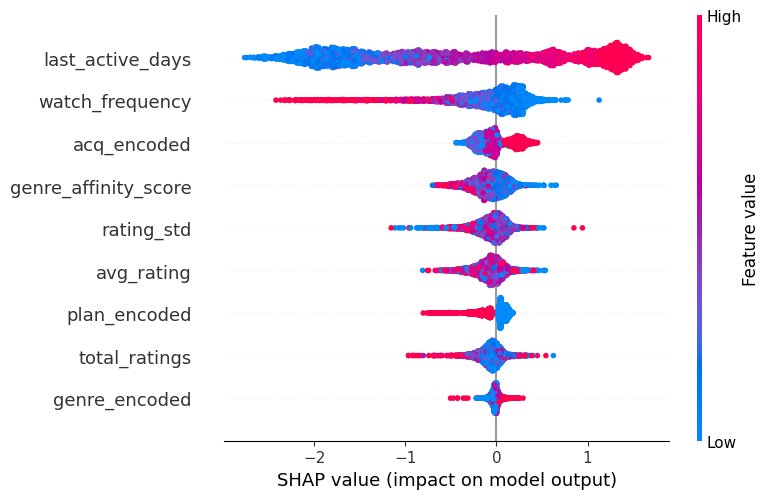

                feature  importance
3      last_active_days    1.160258
4       watch_frequency    0.319038
8           acq_encoded    0.147454
5  genre_affinity_score    0.143228
2            rating_std    0.129880
1            avg_rating    0.125326
7          plan_encoded    0.118252
0         total_ratings    0.101203
6         genre_encoded    0.034021


In [ ]:
# SHAP feature importance
churn_model_reloaded = joblib.load('churn_model.pkl')

explainer = shap.TreeExplainer(churn_model_reloaded)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols, show=True)

shap_importance = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print(shap_importance)

# Step # 5 Kaplan-Meier Cohort Retention Curve

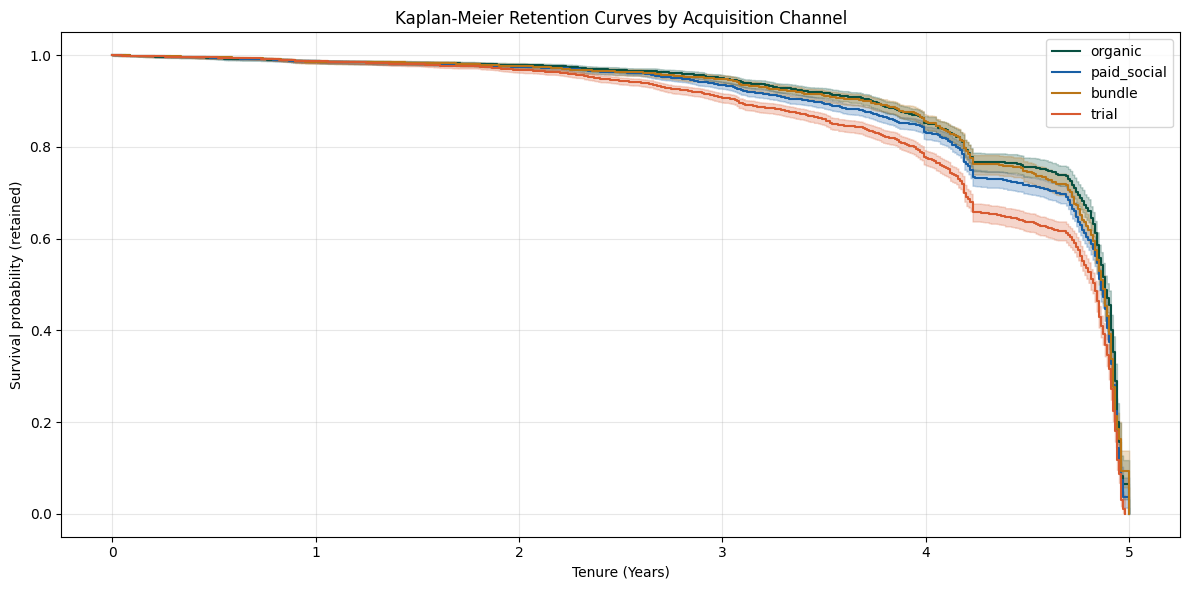


Median survival duration by channel:
  organic      : 4.9 units
  paid_social  : 4.9 units
  bundle       : 4.9 units
  trial        : 4.8 units


In [ ]:
# Create duration and event columns
# Duration = how long subscriber was active (tenure_months proxy)
# Event = did they churn (1 = yes, 0 = censored/still active)
# Rescale tenure to 0-5 year range
max_tenure = features['tenure_months'].max()
features['duration'] = (features['tenure_months'] / max_tenure * 5).round(2)
features['event']    = features['churned']

kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(12, 6))

# Plot survival curve per acquisition channel
colors = {'organic':'#085041', 'paid_social':'#185FA5',
          'bundle':'#BA7517', 'trial':'#D85A30'}

for channel in ['organic', 'paid_social', 'bundle', 'trial']:
    mask = features['acq_channel'] == channel
    kmf.fit(
        durations = features.loc[mask, 'duration'],
        event_observed = features.loc[mask, 'event'],
        label = channel
    )
    kmf.plot_survival_function(ax=ax, color=colors[channel])

ax.set_title('Kaplan-Meier Retention Curves by Acquisition Channel')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Survival probability (retained)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print median survival per channel
print("\nMedian survival duration by channel:")
for channel in ['organic', 'paid_social', 'bundle', 'trial']:
    mask = features['acq_channel'] == channel
    kmf.fit(
        durations = features.loc[mask, 'duration'],
        event_observed = features.loc[mask, 'event']
    )
    print(f"  {channel:12} : {kmf.median_survival_time_:.1f} units")

# Step # 6 Saving Models and Artifacts

In [ ]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Save churn model
joblib.dump(churn_model, 'models/churn_model.pkl')
print("churn_model.pkl saved")

# Save feature columns list — API needs exact same column order
joblib.dump(feature_cols, 'models/feature_cols.pkl')
print("feature_cols.pkl saved")

# Save Kaplan-Meier curves data — for dashboard visualisation
km_data = {}
for channel in ['organic', 'paid_social', 'bundle', 'trial']:
    mask = features['acq_channel'] == channel
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations      = features.loc[mask, 'duration'],
        event_observed = features.loc[mask, 'event'],
        label          = channel
    )
    km_data[channel] = {
        'timeline'   : kmf.survival_function_.index.tolist(),
        'survival'   : kmf.survival_function_[channel].tolist()
    }

joblib.dump(km_data, 'models/km_curves.pkl')
print("km_curves.pkl saved")

# Save SHAP importance — for dashboard feature importance chart
shap_importance.to_csv('models/shap_importance.csv', index=False)
print("shap_importance.csv saved")

# Save full features table — for win-back optimizer
features.to_csv('models/subscriber_features.csv', index=False)
print("subscriber_features.csv saved")

# Save Markov chain parameters
import json
markov_params = {
    'discount_rate'  : 0.01,
    'horizon_months' : 24,
    'plan_prices'    : {'Basic': 9.99, 'Standard': 15.49, 'Premium': 22.99}
}
with open('models/markov_params.json', 'w') as f:
    json.dump(markov_params, f)
print("markov_params.json saved")

# Summary
print("\n" + "="*40)
print("ALL ARTIFACTS SAVED")
print("="*40)
print(f"churn_model.pkl      — XGBoost churn classifier")
print(f"feature_cols.pkl     — feature column order")
print(f"km_curves.pkl        — Kaplan-Meier curve data")
print(f"shap_importance.csv  — SHAP feature importance")
print(f"subscriber_features.csv — full dataset")
print(f"markov_params.json   — Markov chain parameters")

churn_model.pkl saved
feature_cols.pkl saved
km_curves.pkl saved
shap_importance.csv saved
subscriber_features.csv saved
markov_params.json saved

ALL ARTIFACTS SAVED
churn_model.pkl      — XGBoost churn classifier
feature_cols.pkl     — feature column order
km_curves.pkl        — Kaplan-Meier curve data
shap_importance.csv  — SHAP feature importance
subscriber_features.csv — full dataset
markov_params.json   — Markov chain parameters


In [ ]:
shutil.make_archive('models', 'zip', 'models')
files.download('models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>